# LDA 線性判別分析 (Linear Discriminant Analysis)

學習目標：
- 了解 LDA 和 PCA 的差異
- 用 LDA 把不同類別的資料分開
- 視覺化分類效果

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris

## 1. PCA vs LDA 的差異

PCA：找「資料變異最大」的方向（不管類別）
LDA：找「類別之間差異最大」的方向（有監督）

用運動員比喻：
- PCA：找出最能區分所有運動員個體差異的指標
- LDA：找出最能區分「不同運動項目」的指標

In [2]:
# 載入資料
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'資料形狀：{X.shape}')
print(f'類別：{labels}')

資料形狀：(150, 4)
類別：['setosa' 'versicolor' 'virginica']


In [3]:
# PCA 降到2維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA 降到2維
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print('PCA 解釋變異：',
      [f'{r*100:.1f}%' for r in pca.explained_variance_ratio_])
print('LDA 解釋變異：',
      [f'{r*100:.1f}%' for r in lda.explained_variance_ratio_])

PCA 解釋變異： ['73.0%', '22.9%']
LDA 解釋變異： ['99.1%', '0.9%']


/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 24942 (\N{CJK UNIFIED IDEOGRAPH-616E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6423/1848099503.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS

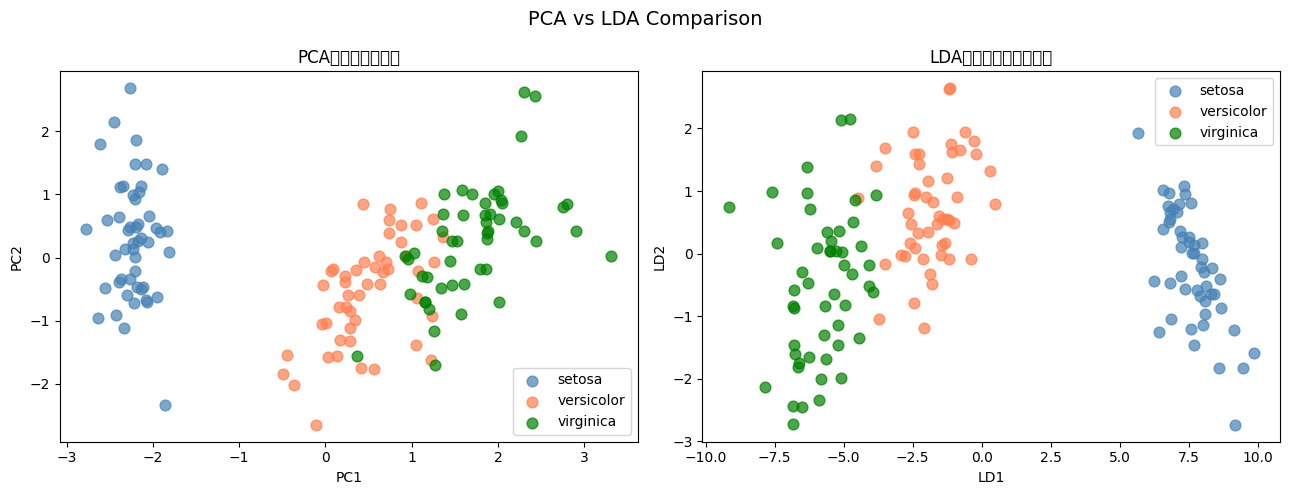

In [4]:
# 並排比較 PCA vs LDA
colors = ['steelblue', 'coral', 'green']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (label, color) in enumerate(zip(labels, colors)):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=label, color=color, alpha=0.7, s=60)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    label=label, color=color, alpha=0.7, s=60)

axes[0].set_title('PCA（不考慮類別）')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].set_title('LDA（最大化類別差異）')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend()

plt.suptitle('PCA vs LDA Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 2. 我的學習筆記

1. 這個主題在做什麼：
   LDA 找出最能區分不同類別的方向，
   讓同類別的點聚在一起，不同類別的點分得越開越好。

2. PCA vs LDA 一句話總結：
   - PCA：無監督，只看資料分布
   - LDA：有監督，利用類別標籤

3. 我覺得最難理解的地方：
   步驟還需熟練
  

4. 這個跟我研究的連結：
   如果要分類「菁英選手 vs 一般選手」，
   LDA 能找出最能區分兩者的身體指標組合，
   比 PCA 更適合分類任務。